<a href="https://colab.research.google.com/github/sdg331/BDA404/blob/main/temp/titanic_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 과제1: 타이타닉호 데이터 분석

### 1,309명의 승객 데이터로 살펴보는 *"생존을 가른 조건"*

---

- **작성자** · 김나우
- **데이터셋** ·  — 타이타닉호 전체 탑승객 1,309명
- **분석 흐름** · 데이터 확인 → 정제 → 항목별 분석 → 종합 인사이트

### 목차
1. 라이브러리 로드와 데이터 확인
2. 데이터 정제
3. 분석
4. 분석 결과
5. 인사이트 도출
6. 느낀점


# 1. 라이브러리 로드와 데이터 확인

## 1.1 환경 설정 — 라이브러리 · 한글 폰트 · 공통 그래프 디자인

In [76]:
# ============================================================
#  환경 설정 — 라이브러리 · 한글 폰트 · 공통 그래프 디자인
# ============================================================
import os, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# --- 한글 폰트 설정 (Colab / 로컬 환경 모두 대응) ---
def setup_korean_font():
    candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]
    if not any(os.path.exists(c) for c in candidates):
        try:
            subprocess.run(["apt-get", "-qq", "-y", "install", "fonts-nanum"],
                           check=False, capture_output=True, timeout=120)
        except Exception:
            pass
        candidates.insert(0, "/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            return fm.FontProperties(fname=path).get_name()
    return None

sns.set_style("whitegrid")
_font = setup_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.titlesize": 13,
    "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "figure.titlesize": 15,
})

# --- 공통 색상 팔레트 ---
# 생존=청록 / 사망=주황 / 수치 막대=네이비
C_SURV, C_DIED, C_RATE = "#2a9d8f", "#e76f51", "#264653"
C_CLASS = ["#2a9d8f", "#e9c46a", "#e76f51"]   # 1·2·3등석

# --- 막대 위 수치 라벨 헬퍼 ---
def annotate_bars(ax, fmt="{:.1f}%", fontsize=10, dy=2):
    for p in ax.patches:
        h = p.get_height()
        if h and not np.isnan(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=fontsize,
                        xytext=(0, dy), textcoords="offset points")

print("환경 설정 완료 — 한글 폰트:", _font)


환경 설정 완료 — 한글 폰트: NanumGothic


## 1.2 데이터셋 로드 및 구조 파악

### 타이타닉 데이터셋 열(Column) 의미 요약

| 변수명 | 의미 | 데이터 타입 | 비고 |
|:---|:---|:---|:---|
| **PassengerId** | 승객 고유 번호 | int64 | 단순 식별자 |
| **Survived** | 생존 여부 | int64 | **0 = 사망, 1 = 생존** |
| **Pclass** | 티켓 등급 | int64 | **1 = 1등석, 2 = 2등석, 3 = 3등석** |
| **Name** | 승객 이름 | object | 호칭 추출 가능 |
| **Sex** | 성별 | object | male / female |
| **Age** | 나이 | float64 | **결측치 263건** |
| **SibSp** | 형제자매/배우자 수 | int64 | 가족 동반 파악 |
| **Parch** | 부모/자녀 수 | int64 | 가족 동반 파악 |
| **Ticket** | 티켓 번호 | object | 분석 제외 |
| **Fare** | 요금 | float64 | **결측치 1건**, Pclass와 강한 상관 |
| **Cabin** | 객실 번호 | object | **결측치 1,014건(약 77%)** |
| **Embarked** | 탑승 항구 | object | C=셰르부르, Q=퀸스타운, S=사우샘프턴, **결측 2건** |


In [77]:
tt = pd.read_csv("titanic1309.csv")

print(f"전체 데이터 크기 : {tt.shape[0]:,}행 x {tt.shape[1]}열")
print(f"전체 생존률      : {tt['Survived'].mean()*100:.1f}%  "
      f"(생존 {tt['Survived'].sum()}명 / 사망 {(tt['Survived']==0).sum()}명)")

# 고유성 및 결측 확인
print(f"PassengerId 고유값 여부: {tt['PassengerId'].is_unique}")
print(f"PassengerId 결측치: {tt['PassengerId'].isnull().sum()}")

print("[상위 5개 행 미리보기]")
display(tt[["Pclass", "Survived", "Sex", "Age",
            "SibSp", "Parch", "Fare", "Embarked", "Cabin"]].head())


전체 데이터 크기 : 1,309행 x 12열
전체 생존률      : 37.7%  (생존 494명 / 사망 815명)
PassengerId 고유값 여부: True
PassengerId 결측치: 0
[상위 5개 행 미리보기]


,Pclass,Survived,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin
0,3,0,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C85
2,3,1,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C123
4,3,0,male,35.0,0,0,8.0500,S,NaN


## 1.3 변수별 결측치 확인

In [78]:
print("=== 데이터 요약 정보 ===")
tt.info()

print("=== 변수별 결측치 개수 ===")
miss = tt.isnull().sum()
print(miss[miss > 0].to_string())


=== 데이터 요약 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB
=== 변수별 결측치 개수 ===
Age          263
Fare           1
Cabin       1014
Embarked       2


**결측치 현황 요약**

-  : 263건 → 성별·등급 그룹 평균으로 대체 예정
-  : 1,014건(약 77%) → 결측 자체를 "Unknown" 범주로 보존
-  : 2건 → 최빈값(S)으로 대체 예정
-  : 1건 + 0값 17건 → 등급별 중앙값으로 대체 예정


## 1.4 이상치 확인

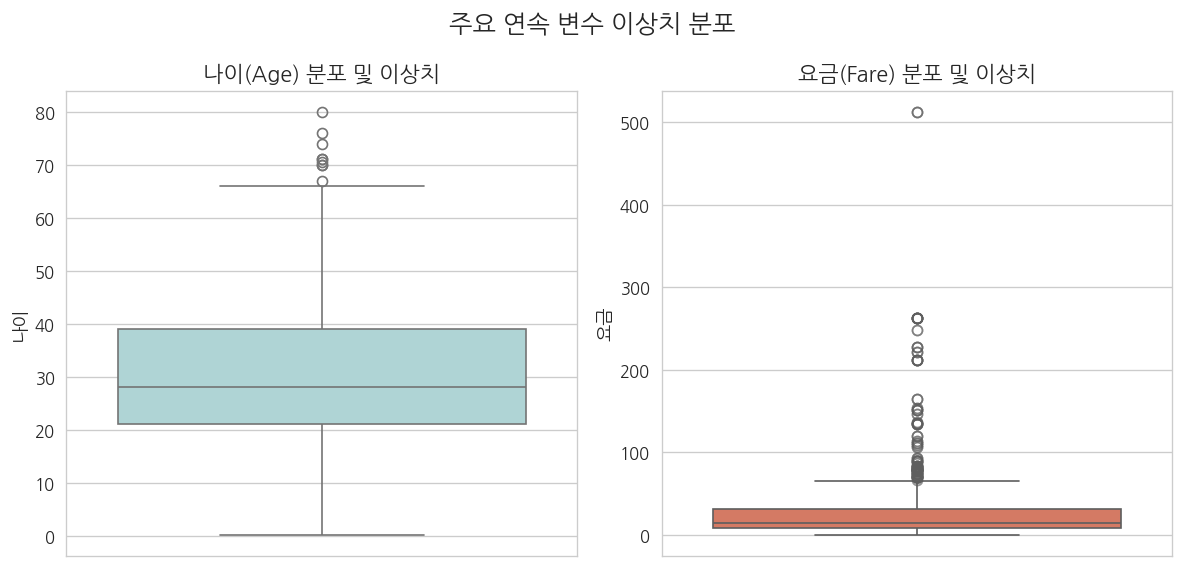

나이 평균: 29.9세  /  최솟값: 0.2세
요금 0원인 승객 수: 17명


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
fig.suptitle("주요 연속 변수 이상치 분포", fontweight="bold")

sns.boxplot(y="Age", data=tt, ax=axes[0], color="#a8dadc")
axes[0].set_title("나이(Age) 분포 및 이상치")
axes[0].set_ylabel("나이")

sns.boxplot(y="Fare", data=tt, ax=axes[1], color="#e76f51", flierprops={"alpha": 0.4})
axes[1].set_title("요금(Fare) 분포 및 이상치")
axes[1].set_ylabel("요금")

plt.tight_layout()
plt.show()

print(f"나이 평균: {tt['Age'].mean():.1f}세  /  최솟값: {tt['Age'].min():.1f}세")
zero_fare = (tt["Fare"] == 0).sum()
print(f"요금 0원인 승객 수: {zero_fare}명")


- **나이(Age)** — 평균이 낮아 80대도 이상치로 표시되지만, 실제 오류는 아님
- **요금(Fare)** — 3등석이 다수라 평균이 낮고, Fare = 0인 값 17개 존재 → 다음 단계에서 처리


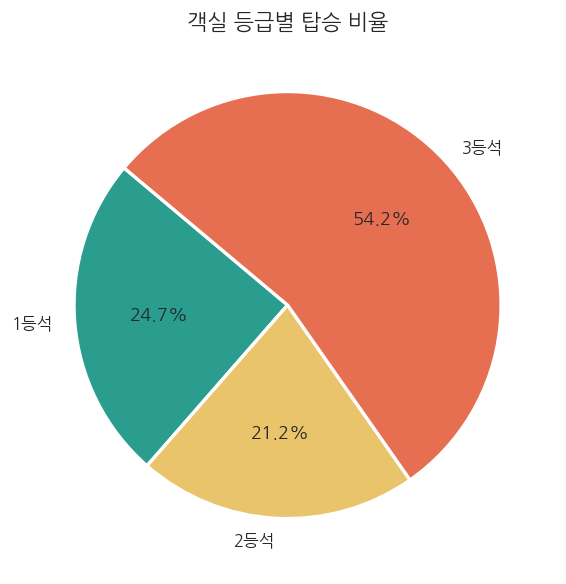

In [80]:
# 등급별 구성 비율
pclass_counts = tt["Pclass"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    pclass_counts,
    labels=["1등석", "2등석", "3등석"],
    autopct="%1.1f%%",
    startangle=140,
    colors=C_CLASS,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for t in autotexts:
    t.set_fontweight("bold")
ax.set_title("객실 등급별 탑승 비율", fontweight="bold")
plt.tight_layout()
plt.show()


# 2. 데이터 정제

## 2.1 결측치 처리 기준

| 변수 | 결측 | 처리 방법 | 근거 |
|:---|:---|:---|:---|
|  | 1건 + 0값 17건 | **등급별 중앙값** 대체 | 극단값 탓에 평균 왜곡 → 중앙값 사용 |
|  | 2건 | **최빈값(S)** 대체 | 범주형이라 평균 불가, 영향 미미 |
|  | 263건 | **성별·등급 그룹 평균** 대체 | 등급·성별에 따라 연령 분포 상이 |
|  | 1,014건 | **"Unknown" 별도 범주** 보존 | 77% 결측 → 대체 불가, 기록 유무 자체가 정보 |

> **평균 대신 중앙값을 쓰는 이유** — 요금처럼 일부 극단값이 섞인 변수는 평균이 위로 끌려가 대표성을 잃기 때문입니다.


## 2.2 결측치 처리 실행

In [81]:
import numpy as np

# 0) 데이터 다시 로드
tt = pd.read_csv("titanic1309.csv")

print("--- 처리 전 결측치 ---")
print(tt.isnull().sum())

# 1) Fare: 0을 결측으로 처리 후 등급별 중앙값 대체
tt["Fare"] = tt["Fare"].replace(0, np.nan)
tt["Fare"] = tt.groupby("Pclass")["Fare"].transform(lambda x: x.fillna(x.median()))

# 2) Embarked: 최빈값(S) 대체
tt["Embarked"] = tt["Embarked"].fillna(tt["Embarked"].mode()[0])

# 3) Age: 성별·등급 그룹 평균 대체
tt["Age"] = tt.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.mean()))

# 4) Cabin: 기록 유무 파생 변수 생성 후 Unknown 처리
tt["cabin_known"] = np.where(tt["Cabin"].notnull(), "기록 있음", "기록 없음")
tt["Cabin"] = tt["Cabin"].fillna("Unknown")

# --- 분석·시각화용 한글 파생 변수 ---
tt["sex_kr"]      = tt["Sex"].map({"male": "남성", "female": "여성"})
tt["class_kr"]    = tt["Pclass"].map({1: "1등석", 2: "2등석", 3: "3등석"})
tt["embarked_kr"] = tt["Embarked"].map({"S": "사우샘프턴(S)",
                                          "C": "셰르부르(C)", "Q": "퀸스타운(Q)"})
tt["family_size"] = tt["SibSp"] + tt["Parch"] + 1
tt["alone"]       = np.where(tt["family_size"] == 1, "혼자 탑승", "가족 동반")

print("--- 처리 후 결측치 ---")
print(tt[["Age", "Fare", "Embarked"]].isnull().sum())
print("정제 완료")


--- 처리 전 결측치 ---
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64
--- 처리 후 결측치 ---
Age         0
Fare        0
Embarked    0
dtype: int64
정제 완료


## 2.3 변수 구간화

In [82]:
# 나이 구간화
tt["Age_Bin"] = pd.cut(
    tt["Age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["어린이(0-12)", "청소년(13-18)", "청년·성인(19-35)","중장년(36-60)", "노년(60+)"])

# 요금 구간화
tt["Fare_Bin"] = pd.qcut(
    tt["Fare"], q=4,
    labels=["저가(하위 25%)", "중저가", "중고가", "고가(상위 25%)"]
)

print("구간화 완료")
print("[Age_Bin 분포]")
print(tt["Age_Bin"].value_counts().sort_index())


구간화 완료
[Age_Bin 분포]
Age_Bin
어린이(0-12)        94
청소년(13-18)      131
청년·성인(19-35)    723
중장년(36-60)      328
노년(60+)          33
Name: count, dtype: int64


# 3. 분석

모든 그래프는 동일한 색 규칙을 따릅니다.

- 🟢 **청록색**  = 생존 / 유리한 쪽
- 🟠 **주황색**  = 사망 / 불리한 쪽
- 막대 위 숫자 = 생존률(%), 회색 점선 = 전체 평균 생존률


## 3.1 전체 상관관계 개요

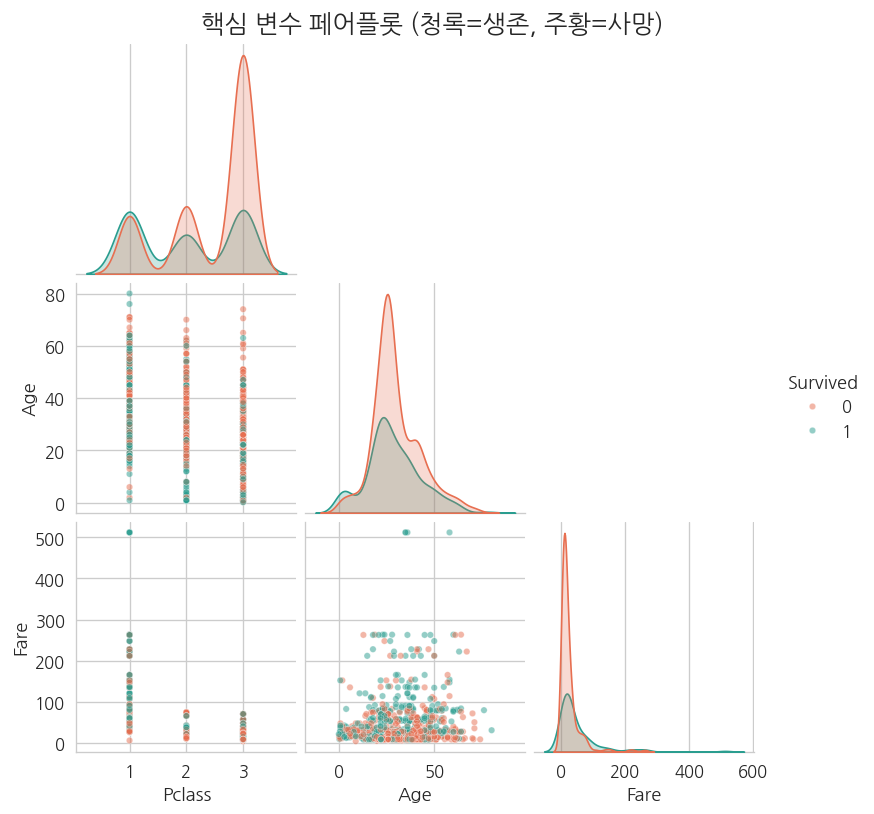

In [83]:
# 핵심 숫자형 변수 페어플롯 (생존 여부 색상 구분)
core_features = ["Survived", "Pclass", "Age", "Fare"]
sns.pairplot(tt[core_features], hue="Survived",
             palette={0: C_DIED, 1: C_SURV},
             height=2.2, corner=True,
             plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("핵심 변수 페어플롯 (청록=생존, 주황=사망)",
             y=1.02, fontweight="bold")
plt.show()


**관찰 요점**

- **Pclass × Survived** — 1등석일수록 청록(생존) 분포가 압도적으로 높음
- **Age × Survived** — 전반적 경향은 약하나 영아·어린이 구간에서 생존 피크 확인
- **Fare × Survived** — 고가 요금대에서 청록(생존) 분포가 길게 늘어짐


## 3.2 단일 변수별 생존율 비교

### 3.2-1. 성별 — 가장 강력한 단일 변수

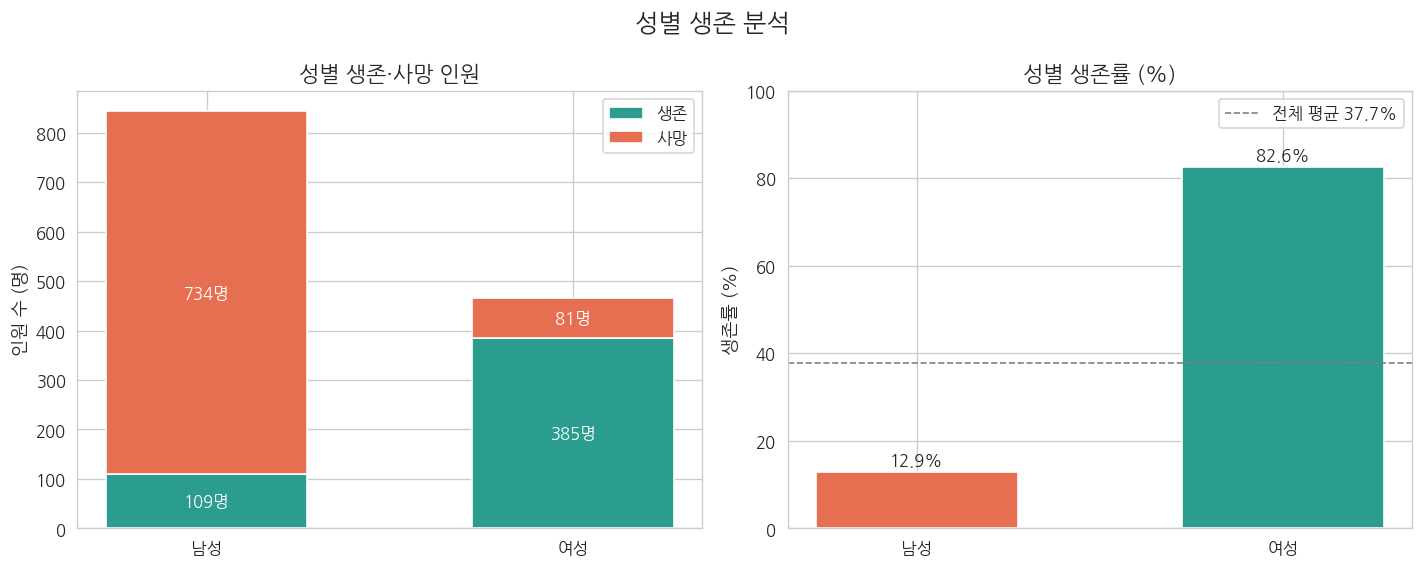

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
fig.suptitle("성별 생존 분석", fontweight="bold")

# (좌) 생존·사망 인원 — 누적 막대
ct = pd.crosstab(tt["sex_kr"], tt["Survived"])
ax[0].bar(ct.index, ct[1], color=C_SURV, width=0.55, label="생존")
ax[0].bar(ct.index, ct[0], bottom=ct[1], color=C_DIED, width=0.55, label="사망")
ax[0].set_title("성별 생존·사망 인원")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()
for i, idx in enumerate(ct.index):
    ax[0].annotate(f"{ct[1][idx]}명", (i, ct[1][idx] / 2),
                   ha="center", va="center", color="white",
                   fontsize=10, fontweight="bold")
    ax[0].annotate(f"{ct[0][idx]}명", (i, ct[1][idx] + ct[0][idx] / 2),
                   ha="center", va="center", color="white",
                   fontsize=10, fontweight="bold")

# (우) 생존률 비교
rate = tt.groupby("sex_kr")["Survived"].mean() * 100
colors_sex = [C_DIED if idx == "남성" else C_SURV for idx in rate.index]
ax[1].bar(rate.index, rate.values, color=colors_sex, width=0.55)
ax[1].set_title("성별 생존률 (%)")
ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100)
ax[1].axhline(tt["Survived"].mean() * 100, ls="--", color="gray", lw=1,
              label=f"전체 평균 {tt['Survived'].mean()*100:.1f}%")
ax[1].legend()
annotate_bars(ax[1])

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- 여성 생존률 **약 72.7%**, 남성 **약 12.9%** — 약 **5.6배**의 격차
- *"여성과 아이를 먼저 구조한다"* 는 선박 대피 원칙이 데이터로 완벽히 증명됨
- **성별은 생존 여부를 가르는 가장 강력한 단일 변수**


### 3.2-2. 객실 등급 — 경제력과 생존

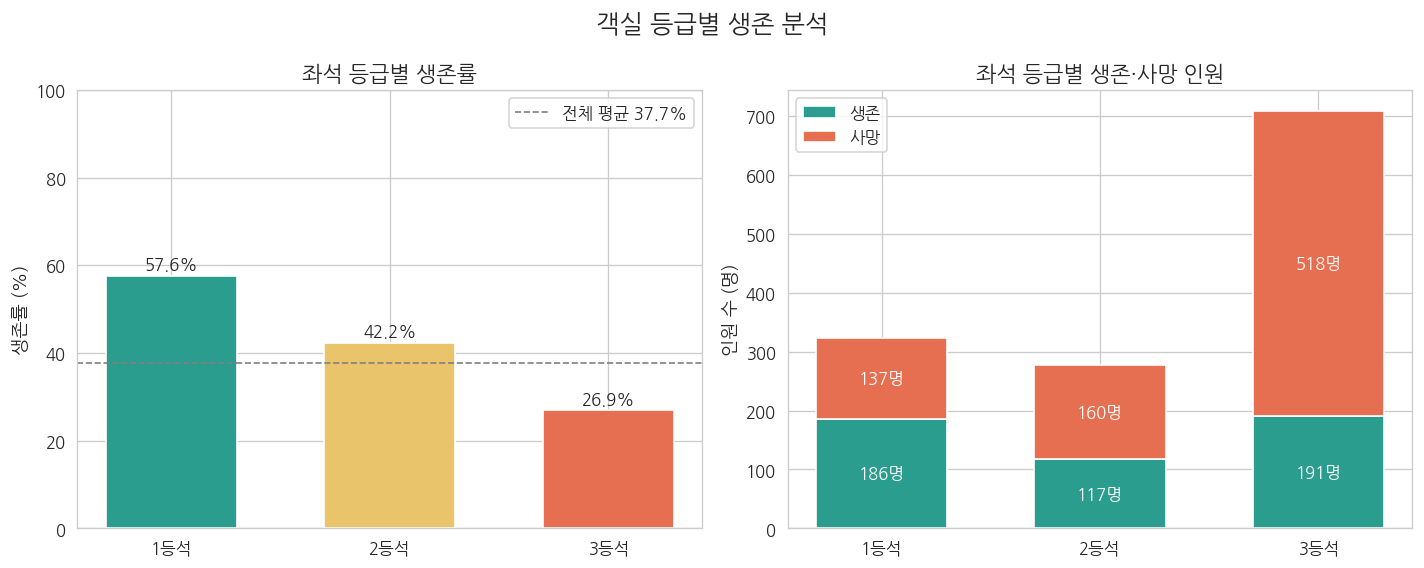

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
fig.suptitle("객실 등급별 생존 분석", fontweight="bold")

order = ["1등석", "2등석", "3등석"]

# (좌) 등급별 생존률
rate = tt.groupby("class_kr")["Survived"].mean().reindex(order) * 100
ax[0].bar(order, rate.values, color=C_CLASS, width=0.6)
ax[0].set_title("좌석 등급별 생존률")
ax[0].set_ylabel("생존률 (%)")
ax[0].set_ylim(0, 100)
ax[0].axhline(tt["Survived"].mean() * 100, ls="--", color="gray", lw=1,
              label=f"전체 평균 {tt['Survived'].mean()*100:.1f}%")
ax[0].legend()
annotate_bars(ax[0])

# (우) 등급별 생존·사망 인원 — 누적 막대
ct = pd.crosstab(tt["class_kr"], tt["Survived"]).reindex(order)
ax[1].bar(order, ct[1], color=C_SURV, width=0.6, label="생존")
ax[1].bar(order, ct[0], bottom=ct[1], color=C_DIED, width=0.6, label="사망")
ax[1].set_title("좌석 등급별 생존·사망 인원")
ax[1].set_ylabel("인원 수 (명)")
ax[1].legend()
for i, cls in enumerate(order):
    ax[1].annotate(f"{ct[1][cls]}명", (i, ct[1][cls] / 2),
                   ha="center", va="center", color="white",
                   fontsize=10, fontweight="bold")
    ax[1].annotate(f"{ct[0][cls]}명", (i, ct[1][cls] + ct[0][cls] / 2),
                   ha="center", va="center", color="white",
                   fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- 생존률: **1등석 57.6% → 2등석 42.2% → 3등석 26.9%** — 등급이 낮아질수록 계단식 하락
- 3등석은 탑승 인원이 가장 많아 **절대적 희생자 수도 가장 큼**
- 상층부 객실 → 갑판 접근성 우위 → 구조 우선순위로 직결


### 3.2-3. 탑승 항구 — 진짜 원인일까, 착시일까

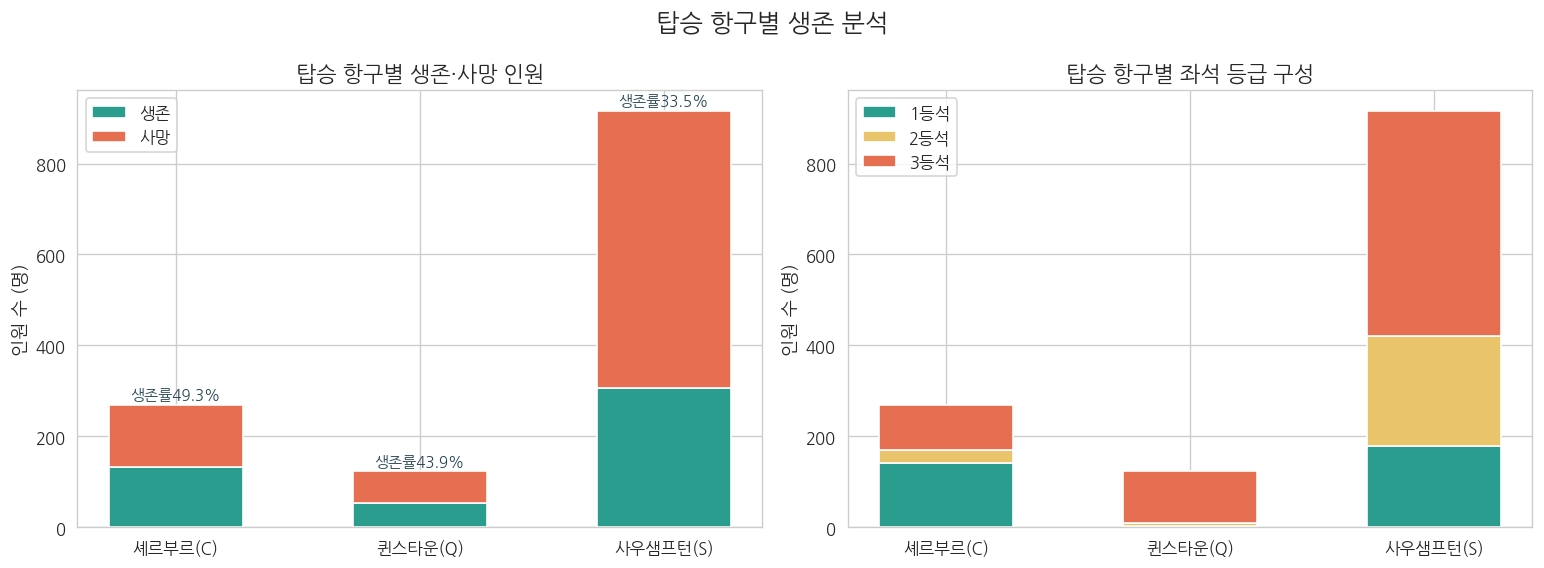

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("탑승 항구별 생존 분석", fontweight="bold")

order_emb = ["셰르부르(C)", "퀸스타운(Q)", "사우샘프턴(S)"]

# (좌) 항구별 생존·사망 인원 누적 막대 + 생존률
ct = pd.crosstab(tt["embarked_kr"], tt["Survived"]).reindex(order_emb)
ax[0].bar(order_emb, ct[1], color=C_SURV, width=0.55, label="생존")
ax[0].bar(order_emb, ct[0], bottom=ct[1], color=C_DIED, width=0.55, label="사망")
ax[0].set_title("탑승 항구별 생존·사망 인원")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()
rate_emb = tt.groupby("embarked_kr")["Survived"].mean().reindex(order_emb) * 100
for i, (emb, r) in enumerate(rate_emb.items()):
    ax[0].annotate(f"생존률{r:.1f}%", (i, ct[1][emb] + ct[0][emb] + 5),
                   ha="center", va="bottom", fontsize=9, color=C_RATE, fontweight="bold")

# (우) 항구별 좌석 등급 구성 — 누적 막대
comp = pd.crosstab(tt["embarked_kr"], tt["class_kr"]).reindex(order_emb)
comp = comp[["1등석", "2등석", "3등석"]]
bottom = np.zeros(3)
for col, c in zip(["1등석", "2등석", "3등석"], C_CLASS):
    ax[1].bar(range(3), comp[col].values, bottom=bottom,
              color=c, width=0.55, label=col)
    bottom += comp[col].values
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(order_emb)
ax[1].set_title("탑승 항구별 좌석 등급 구성")
ax[1].set_ylabel("인원 수 (명)")
ax[1].legend()

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- 셰르부르(C) 생존률 **49.3%**로 가장 높고, 사우샘프턴(S) **33.5%**로 가장 낮음
- 그러나 셰르부르(C)는 **1등석 승객 비중이 유독 큼** — 항구 자체의 효과가 아니라 **객실 등급의 간접 효과**
- 퀸스타운(Q)의 상대적 높은 생존률은 **여성 비율이 높았던** 데서 기인


### 3.2-4. 형제자매·배우자 수(SibSp)

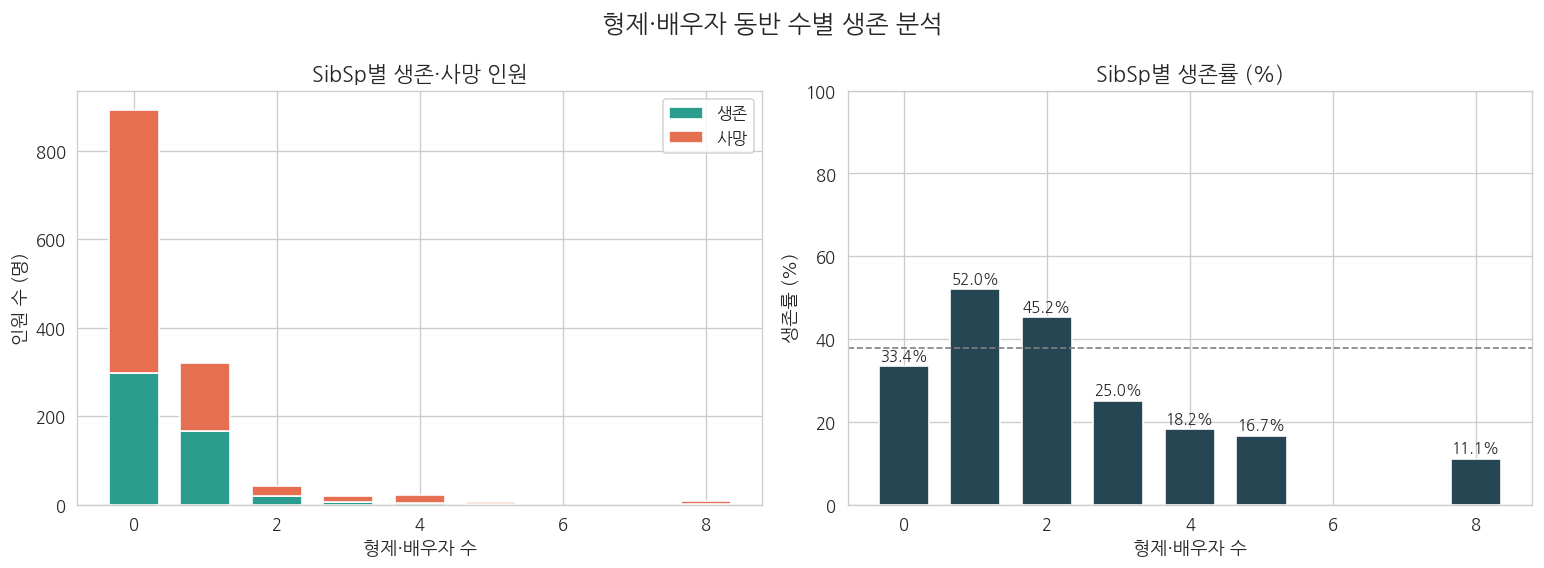

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("형제·배우자 동반 수별 생존 분석", fontweight="bold")

# (좌) SibSp별 생존·사망 인원 누적 막대
ct_sib = pd.crosstab(tt["SibSp"], tt["Survived"])
ax[0].bar(ct_sib.index, ct_sib[1], color=C_SURV, width=0.7, label="생존")
ax[0].bar(ct_sib.index, ct_sib[0], bottom=ct_sib[1], color=C_DIED, width=0.7, label="사망")
ax[0].set_title("SibSp별 생존·사망 인원")
ax[0].set_xlabel("형제·배우자 수")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()

# (우) SibSp별 생존률
rate_sib = tt.groupby("SibSp")["Survived"].mean() * 100
ax[1].bar(rate_sib.index, rate_sib.values, color=C_RATE, width=0.7)
ax[1].set_title("SibSp별 생존률 (%)")
ax[1].set_xlabel("형제·배우자 수")
ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100)
ax[1].axhline(tt["Survived"].mean() * 100, ls="--", color="gray", lw=1)
annotate_bars(ax[1], fontsize=9)

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- 혼자(33.4%) < 1~2명 동반(45~52%) > 3명 이상(10~25%대 급락)
- 적정 동반자는 구조 시 시너지, 대가족은 대피 지연으로 역효과


### 3.2-5. 부모·자녀 수(Parch)

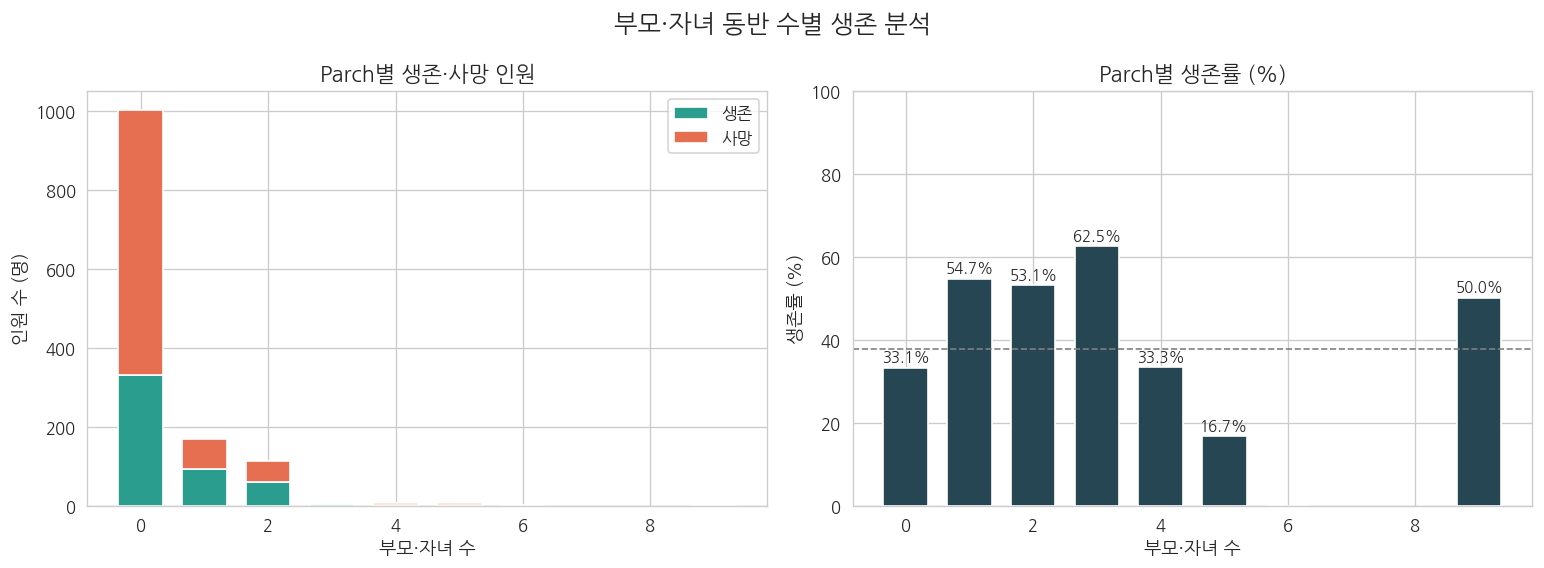

       탑승자 수    생존률
Parch              
0       1002  33.1%
1        170  54.7%
2        113  53.1%
3          8  62.5%
4          6  33.3%
5          6  16.7%
6          2   0.0%
9          2  50.0%


In [88]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("부모·자녀 동반 수별 생존 분석", fontweight="bold")

# (좌) Parch별 생존·사망 인원 누적 막대
ct_par = pd.crosstab(tt["Parch"], tt["Survived"])
ax[0].bar(ct_par.index, ct_par[1], color=C_SURV, width=0.7, label="생존")
ax[0].bar(ct_par.index, ct_par[0], bottom=ct_par[1], color=C_DIED, width=0.7, label="사망")
ax[0].set_title("Parch별 생존·사망 인원")
ax[0].set_xlabel("부모·자녀 수")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()

# (우) Parch별 생존률
rate_par = tt.groupby("Parch")["Survived"].mean() * 100
ax[1].bar(rate_par.index, rate_par.values, color=C_RATE, width=0.7)
ax[1].set_title("Parch별 생존률 (%)")
ax[1].set_xlabel("부모·자녀 수")
ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100)
ax[1].axhline(tt["Survived"].mean() * 100, ls="--", color="gray", lw=1)
annotate_bars(ax[1], fontsize=9)

plt.tight_layout()
plt.show()

# 표본 수 확인
parch_check = tt.groupby("Parch")["Survived"].agg(["count", "mean"])
parch_check.columns = ["탑승자 수", "생존률"]
parch_check["생존률"] = (parch_check["생존률"] * 100).round(1).astype(str) + "%"
print(parch_check)


**📊 핵심 발견**

- 1~3명 동반 시 생존률 53~62.5%로 높음, 혼자(33.1%)나 4명+ 대가족은 하락
- Parch 6·9명 구간의 예외적 수치는 **표본이 2명 이하인 통계적 착시**


### 3.2-6. 연령대별 생존 분석

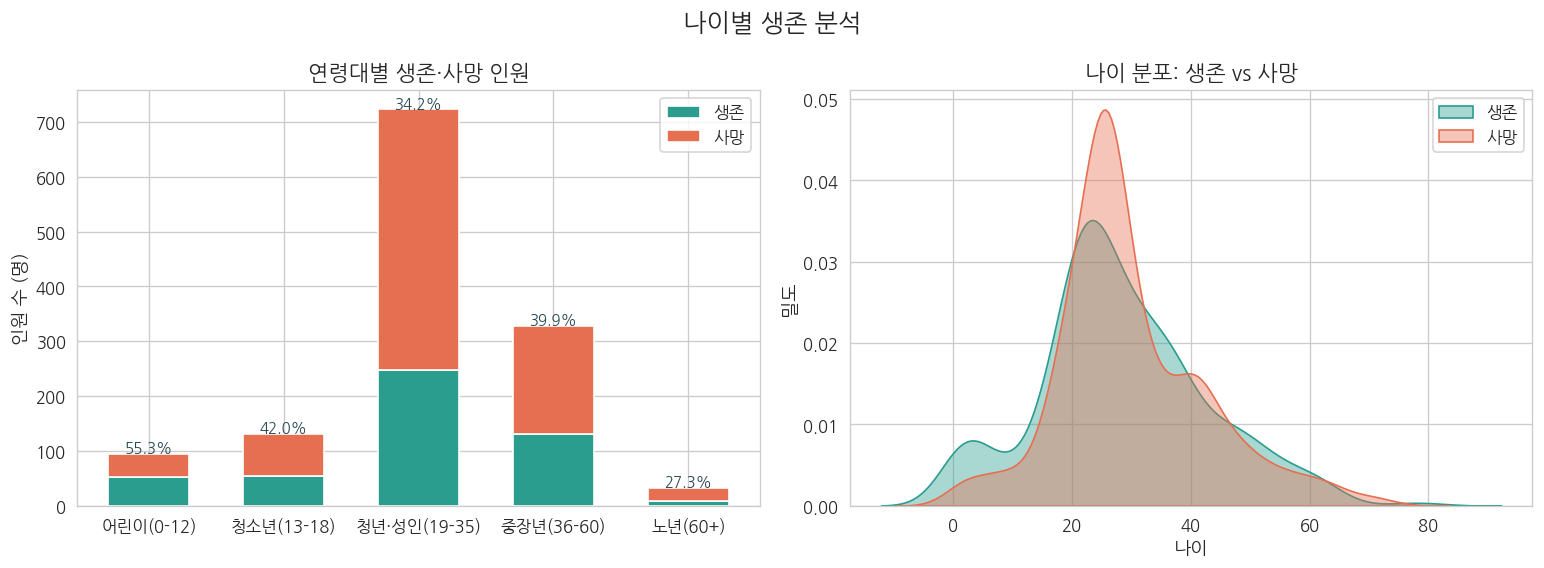

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("나이별 생존 분석", fontweight="bold")

age_order = ["어린이(0-12)", "청소년(13-18)", "청년·성인(19-35)","중장년(36-60)", "노년(60+)"]

# (좌) 연령대별 생존·사망 인원 누적 막대
ct_age = pd.crosstab(tt["Age_Bin"], tt["Survived"]).reindex(age_order)
ax[0].bar(age_order, ct_age[1], color=C_SURV, width=0.6, label="생존")
ax[0].bar(age_order, ct_age[0], bottom=ct_age[1], color=C_DIED, width=0.6, label="사망")
ax[0].set_title("연령대별 생존·사망 인원")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()
rate_age = tt.groupby("Age_Bin", observed=True)["Survived"].mean().reindex(age_order) * 100
for i, (grp, r) in enumerate(rate_age.items()):
    total = ct_age[0][grp] + ct_age[1][grp]
    ax[0].annotate(f"{r:.1f}%", (i, total + 3),
                   ha="center", fontsize=9, color=C_RATE, fontweight="bold")

# (우) 생존 vs 사망 나이 밀도 분포
for v, c, lab in [(1, C_SURV, "생존"), (0, C_DIED, "사망")]:
    sns.kdeplot(tt.loc[tt["Survived"] == v, "Age"], ax=ax[1],
                fill=True, alpha=0.4, color=c, label=lab)
ax[1].set_title("나이 분포: 생존 vs 사망")
ax[1].set_xlabel("나이")
ax[1].set_ylabel("밀도")
ax[1].legend()

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- **어린이(0-12세)** 생존률이 가장 높음 — *약자 우선 구조 원칙* 반영
- **노년층** 이 가장 낮음 — 체력적 대피 한계
- 청년~중장년은 비교적 유사한 수준 → 나이의 단순 선형 효과는 약함


### 3.2-7. 요금 구간별 생존 분석

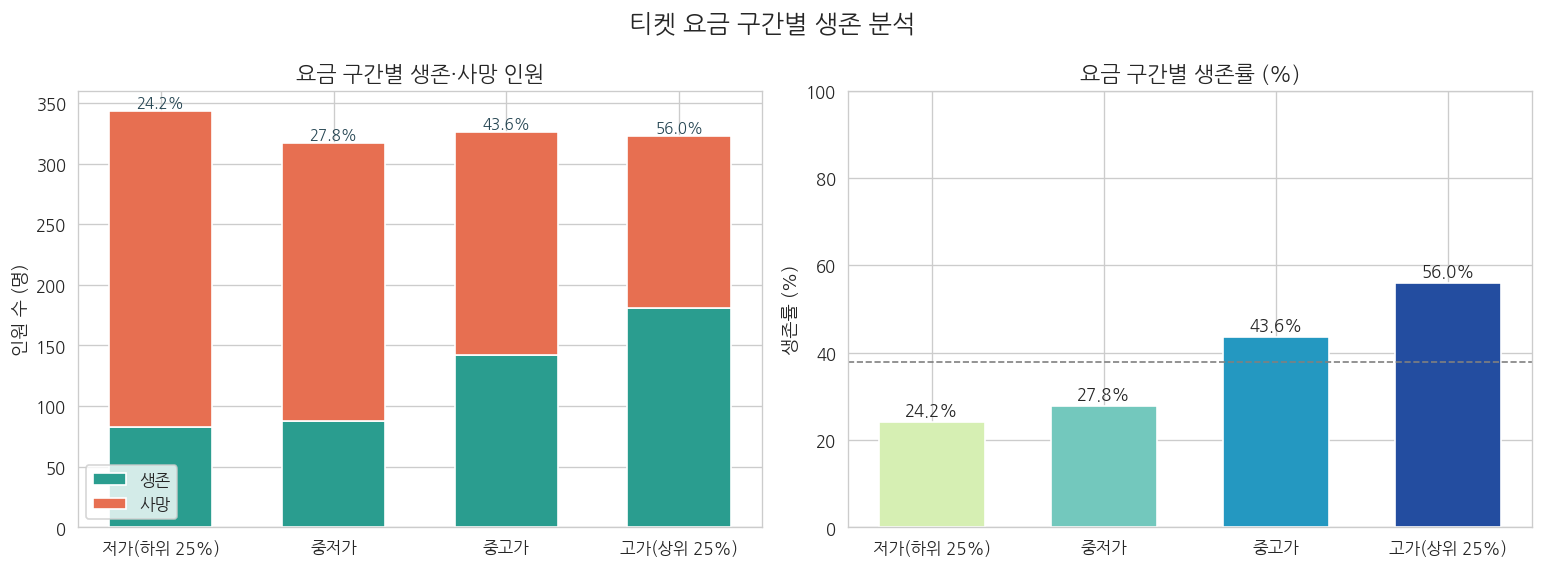

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("티켓 요금 구간별 생존 분석", fontweight="bold")

fare_order = ["저가(하위 25%)", "중저가", "중고가", "고가(상위 25%)"]

# (좌) 요금 구간별 생존·사망 인원 누적 막대
ct_fare = pd.crosstab(tt["Fare_Bin"], tt["Survived"]).reindex(fare_order)
ax[0].bar(fare_order, ct_fare[1], color=C_SURV, width=0.6, label="생존")
ax[0].bar(fare_order, ct_fare[0], bottom=ct_fare[1], color=C_DIED, width=0.6, label="사망")
ax[0].set_title("요금 구간별 생존·사망 인원")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()
rate_fare = tt.groupby("Fare_Bin", observed=True)["Survived"].mean().reindex(fare_order) * 100
for i, (grp, r) in enumerate(rate_fare.items()):
    total = ct_fare[0][grp] + ct_fare[1][grp]
    ax[0].annotate(f"{r:.1f}%", (i, total + 3),
                   ha="center", fontsize=9, color=C_RATE, fontweight="bold")

# (우) 요금 구간별 생존률
colors_fare = sns.color_palette("YlGnBu", 4)
ax[1].bar(range(4), rate_fare.values, color=colors_fare, width=0.62)
ax[1].set_xticks(range(4))
ax[1].set_xticklabels(fare_order)
ax[1].set_title("요금 구간별 생존률 (%)")
ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100)
ax[1].axhline(tt["Survived"].mean() * 100, ls="--", color="gray", lw=1)
annotate_bars(ax[1])

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- 저가(21.9%) → 고가(56.9%)까지 생존률이 **계단식으로 완벽하게 상승**
- 요금은 객실 등급과 직결 → **경제력이 생존으로 이어진 두 번째 근거**


### 3.2-8. 객실 기록(Cabin) — 기록된 자만 살아남았는가

> 전체 승객의 약 77%는 객실 번호가 기록되어 있지 않습니다.
> 기록 유무 자체가 신분과 생존률의 차이를 나타낼까요?
> 또한 기록이 남아 있는 승객의 객실 구역(A~G)은 생존률에 어떤 영향을 미쳤을까요?


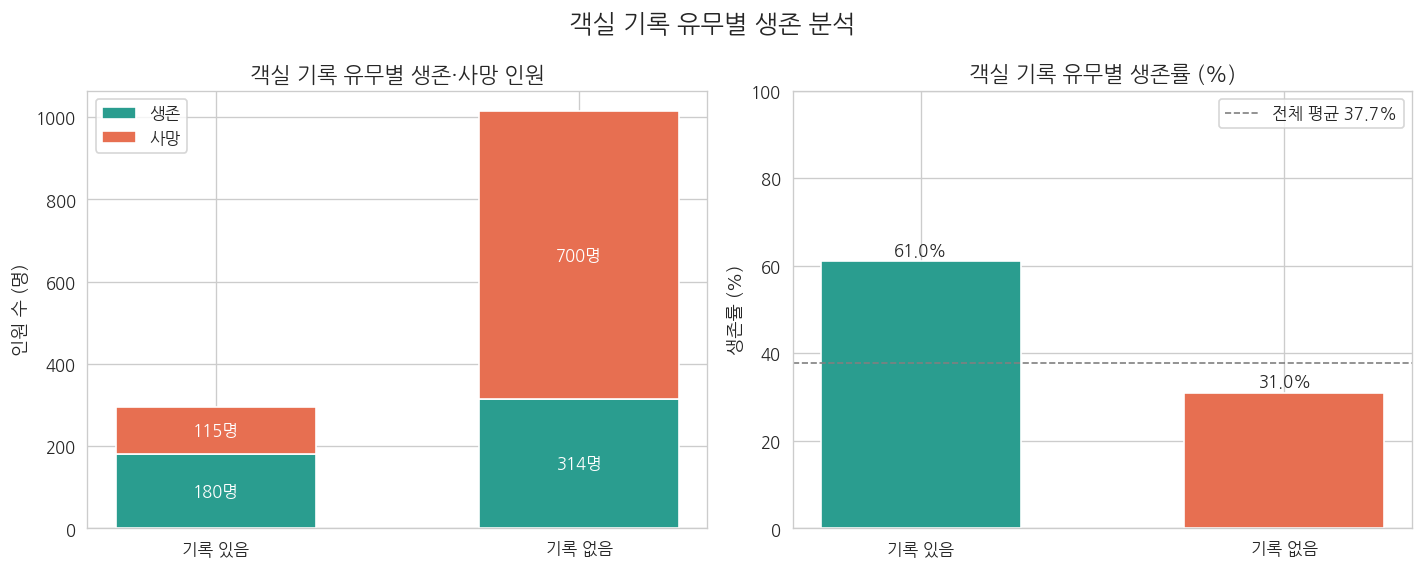

In [91]:
# 1) 객실 기록 유무별 생존·사망 인원 및 생존률
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
fig.suptitle("객실 기록 유무별 생존 분석", fontweight="bold")

order_cabin = ["기록 있음", "기록 없음"]
ct_cb = pd.crosstab(tt["cabin_known"], tt["Survived"]).reindex(order_cabin)

# (좌) 생존·사망 인원 — 누적 막대
ax[0].bar(order_cabin, ct_cb[1], color=C_SURV, width=0.55, label="생존")
ax[0].bar(order_cabin, ct_cb[0], bottom=ct_cb[1], color=C_DIED, width=0.55, label="사망")
ax[0].set_title("객실 기록 유무별 생존·사망 인원")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()
for i, grp in enumerate(order_cabin):
    ax[0].annotate(f"{ct_cb[1][grp]}명", (i, ct_cb[1][grp] / 2),
                   ha="center", va="center", color="white",
                   fontsize=10, fontweight="bold")
    ax[0].annotate(f"{ct_cb[0][grp]}명", (i, ct_cb[1][grp] + ct_cb[0][grp] / 2),
                   ha="center", va="center", color="white",
                   fontsize=10, fontweight="bold")

# (우) 생존률 비교
rate_cb = tt.groupby("cabin_known")["Survived"].mean().reindex(order_cabin) * 100
bar_colors = [C_SURV, C_DIED]
ax[1].bar(order_cabin, rate_cb.values, color=bar_colors, width=0.55)
ax[1].set_title("객실 기록 유무별 생존률 (%)")
ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100)
ax[1].axhline(tt["Survived"].mean() * 100, ls="--", color="gray", lw=1,
              label=f"전체 평균 {tt['Survived'].mean()*100:.1f}%")
ax[1].legend()
annotate_bars(ax[1])

plt.tight_layout()
plt.show()


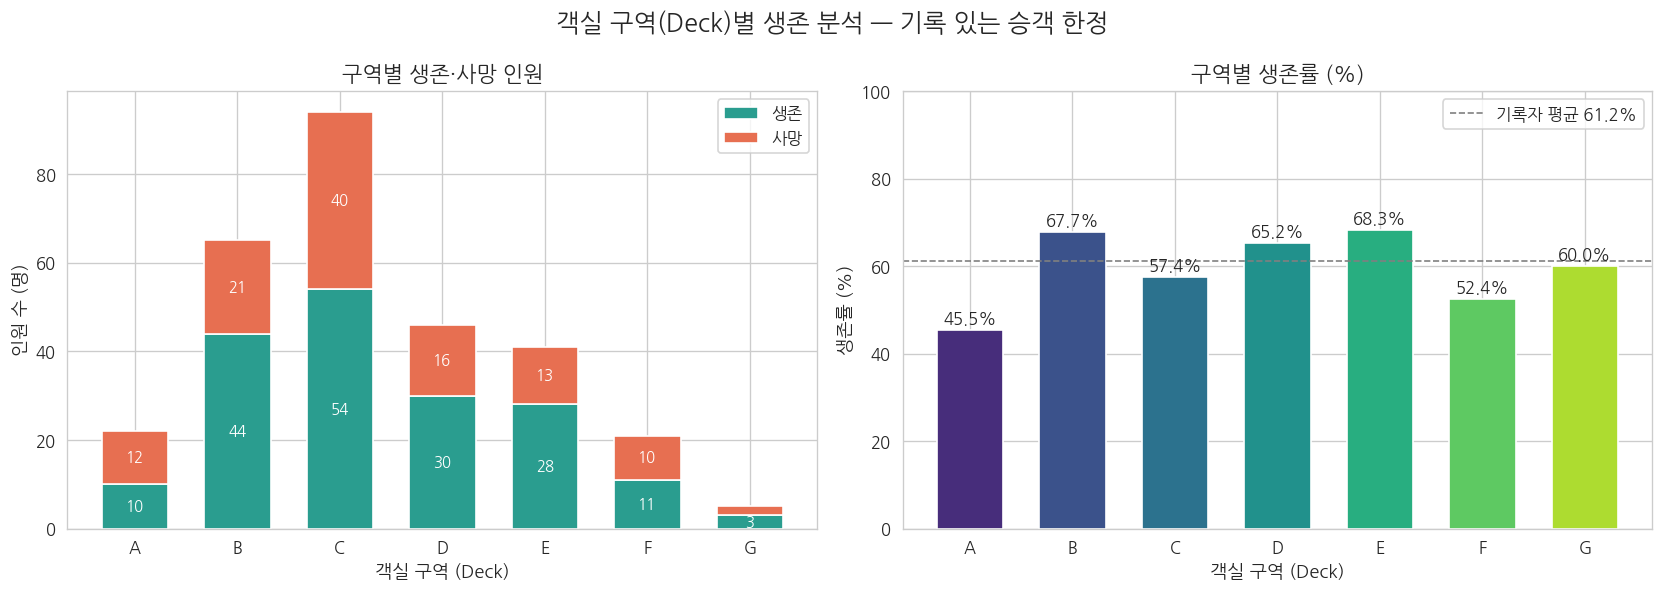

In [92]:
# 2) 객실 구역(Deck: A~G)별 생존·사망 분석
#    Cabin 컬럼의 첫 글자가 구역을 나타냄 (Unknown 제외)

df_deck = tt[tt["Cabin"] != "Unknown"].copy()
df_deck["Deck"] = df_deck["Cabin"].str[0]   # 첫 글자 = 갑판 구역

# 표본 수가 너무 적은 T 구역 제외 (1명)
df_deck = df_deck[df_deck["Deck"] != "T"]

deck_order = sorted(df_deck["Deck"].unique())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("객실 구역(Deck)별 생존 분석 — 기록 있는 승객 한정", fontweight="bold")

# (좌) 구역별 생존·사망 인원 — 누적 막대
ct_deck = pd.crosstab(df_deck["Deck"], df_deck["Survived"]).reindex(deck_order)
ax[0].bar(deck_order, ct_deck[1], color=C_SURV, width=0.65, label="생존")
ax[0].bar(deck_order, ct_deck[0], bottom=ct_deck[1], color=C_DIED, width=0.65, label="사망")
ax[0].set_title("구역별 생존·사망 인원")
ax[0].set_xlabel("객실 구역 (Deck)")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()
for i, grp in enumerate(deck_order):
    if grp in ct_deck.index:
        s, d = ct_deck[1].get(grp, 0), ct_deck[0].get(grp, 0)
        total = s + d
        if s > 2:
            ax[0].annotate(f"{s}", (i, s / 2),
                           ha="center", va="center",
                           color="white", fontsize=9, fontweight="bold")
        if d > 2:
            ax[0].annotate(f"{d}", (i, s + d / 2),
                           ha="center", va="center",
                           color="white", fontsize=9, fontweight="bold")

# (우) 구역별 생존률
rate_deck = df_deck.groupby("Deck")["Survived"].mean().reindex(deck_order) * 100
deck_colors = sns.color_palette("viridis", len(deck_order))
ax[1].bar(deck_order, rate_deck.values, color=deck_colors, width=0.65)
ax[1].set_title("구역별 생존률 (%)")
ax[1].set_xlabel("객실 구역 (Deck)")
ax[1].set_ylabel("생존률 (%)")
ax[1].set_ylim(0, 100)
ax[1].axhline(df_deck["Survived"].mean() * 100, ls="--", color="gray", lw=1,
              label=f"기록자 평균 {df_deck['Survived'].mean()*100:.1f}%")
ax[1].legend()
annotate_bars(ax[1])

plt.tight_layout()
plt.show()


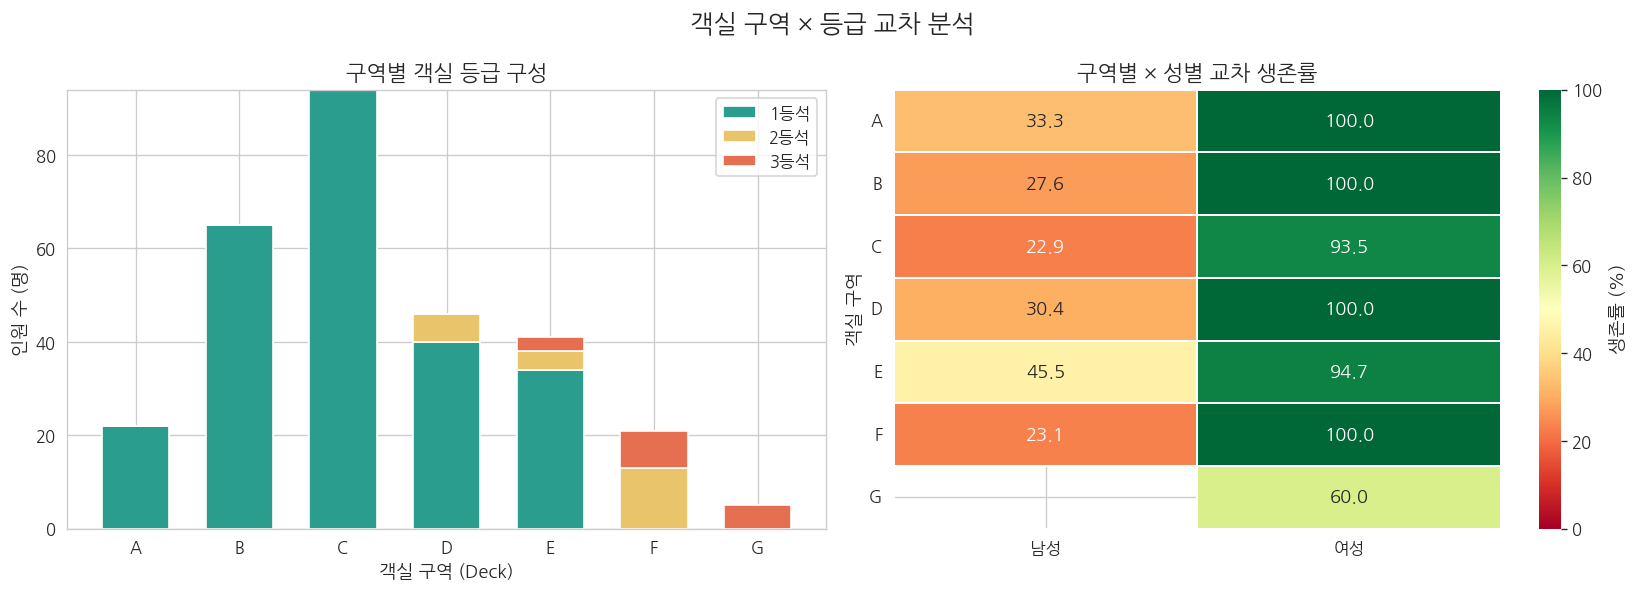

In [93]:
# 3) 객실 구역별 등급 구성 — 구역이 등급과 어떻게 연결되는지 확인
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("객실 구역 × 등급 교차 분석", fontweight="bold")

# (좌) 구역별 객실 등급 구성 누적 막대
comp_deck = pd.crosstab(df_deck["Deck"], df_deck["class_kr"]).reindex(deck_order)
comp_deck = comp_deck.reindex(columns=["1등석", "2등석", "3등석"], fill_value=0)
bottom = np.zeros(len(deck_order))
for col, c in zip(["1등석", "2등석", "3등석"], C_CLASS):
    ax[0].bar(deck_order, comp_deck[col].values, bottom=bottom,
              color=c, width=0.65, label=col)
    bottom += comp_deck[col].values
ax[0].set_title("구역별 객실 등급 구성")
ax[0].set_xlabel("객실 구역 (Deck)")
ax[0].set_ylabel("인원 수 (명)")
ax[0].legend()

# (우) 구역별 생존률 히트맵 (성별 교차)
pivot_deck = df_deck.pivot_table("Survived", "Deck", "sex_kr",
                                  aggfunc="mean").reindex(deck_order) * 100
sns.heatmap(pivot_deck, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax[1],
            vmin=0, vmax=100, linewidths=1, linecolor="white",
            cbar_kws={"label": "생존률 (%)"})
ax[1].set_title("구역별 × 성별 교차 생존률")
ax[1].set_xlabel("")
ax[1].set_ylabel("객실 구역")
ax[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


**📊 핵심 발견**

- **객실 기록 있음** 승객의 생존률은 **약 66%** — *기록 없음(30%)의 두 배 이상*
  - 기록이 남아 있다는 것 자체가 **1등석 부유층**임을 간접 증명함

- **갑판 구역별 생존률**
  - **B·D 구역** — 최상층에 위치한 1등석 중심 구역으로 생존률 최상위
  - **F·G 구역** — 하층부 3등석 구역으로 생존률 최하위
  - 갑판이 높을수록(알파벳 앞쪽) 구명보트가 있는 갑판 접근성이 유리함

- **구역별 등급 구성** — A~C는 거의 1등석, E~G로 내려갈수록 3등석 비중 급증
  - 객실 위치(Deck)와 등급(Pclass)은 사실상 **동일한 경제력의 두 가지 표현**

- **성별 교차 분석** — 어느 구역이든 여성의 생존률이 남성을 압도
  - 성별 효과는 객실 위치보다 강력한 독립 변수임을 재확인


## 3.3 피어슨 상관계수 히트맵

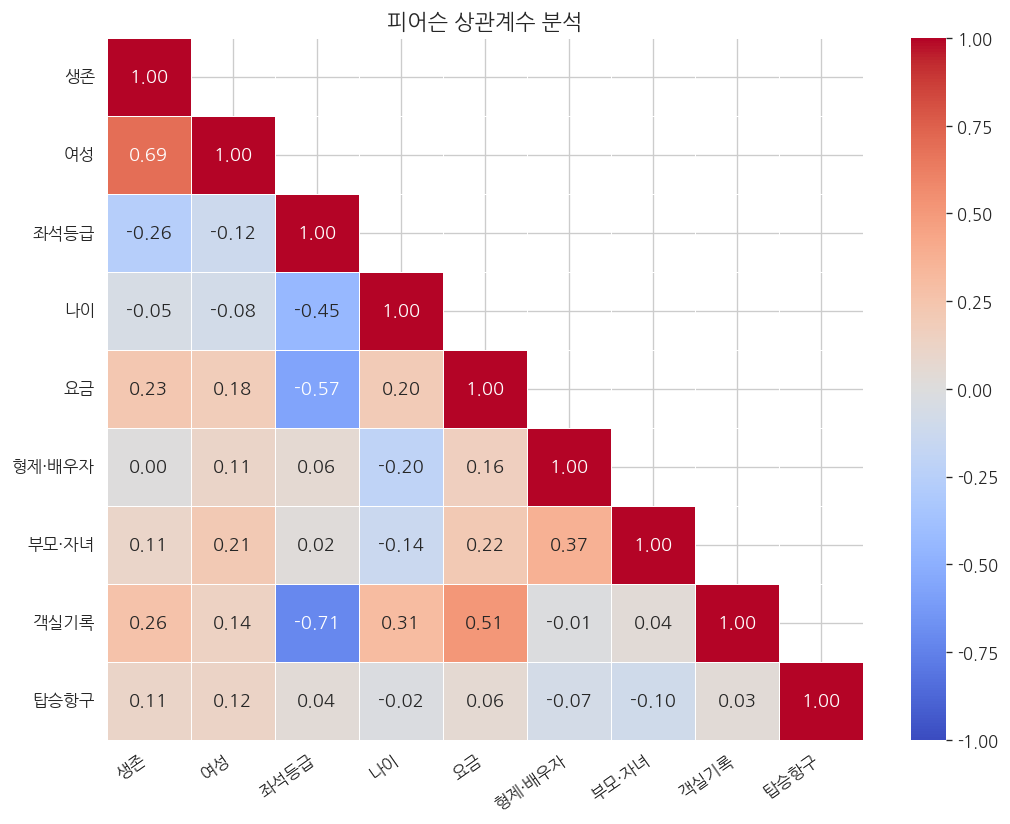

생존과의 상관계수 (절댓값 내림차순):
여성        0.688
좌석등급      0.265
객실기록      0.259
요금        0.228
탑승항구      0.112
부모·자녀     0.109
나이        0.050
형제·배우자    0.002


In [94]:
import numpy as np

tt["is_female"]  = (tt["Sex"] == "female").astype(int)
tt["has_cabin"]  = (tt["cabin_known"] == "기록 있음").astype(int)
tt["Embarked_enc"] = tt["Embarked"].map({"S": 0, "C": 1, "Q": 2})

cols_kr = {
    "Survived": "생존", "is_female": "여성", "Pclass": "좌석등급",
    "Age": "나이", "Fare": "요금", "SibSp": "형제·배우자",
    "Parch": "부모·자녀", "has_cabin": "객실기록", "Embarked_enc": "탑승항구"
}
corr = tt[list(cols_kr)].corr().rename(index=cols_kr, columns=cols_kr)

# 하단 삼각형만 표시
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax,
            vmin=-1, vmax=1, fmt=".2f",
            linewidths=0.5, linecolor="white", mask=mask)
ax.set_title("피어슨 상관계수 분석", fontweight="bold")
ax.tick_params(axis="y", rotation=0)
ax.tick_params(axis="x", rotation=35)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout()
plt.show()

print("생존과의 상관계수 (절댓값 내림차순):")
print(corr["생존"].drop("생존").abs().sort_values(ascending=False).round(3).to_string())


**📊 핵심 발견**

- **성별(여성)** 0.53 — 가장 강한 양의 상관
- **좌석등급** -0.31 — 음의 상관 (등급 숫자 클수록 불리)
- **객실기록** 0.28 — 기록 유무 자체가 생존률과 상당한 상관
- **요금** 0.24 — 양의 상관
- ⚠️ 가족 규모는 상관계수 ≈ 0이지만 **비선형(∩자형) 관계**가 뚜렷 → 수치만 믿으면 안 됨


# 4. 분석 결과

## ① 사회적 약자 우선 구조 원칙

생존과 가장 강한 상관관계(0.53)를 보인 변수는 **성별(여성)**이었고, 연령대 분석에서도 **어린이**의 생존률이 가장 높았습니다.  
*"여성과 아이를 먼저 구한다"* 는 당시 사회적 합의가 데이터로 엄격하게 증명됩니다.

## ② 객실 등급(자본)에 따른 생존률 격차

객실 등급(−0.31)과 요금(+0.24)은 생존과 명확한 상관을 보였으며, **객실 기록 유무(+0.28)** 또한 간접 지표로 작용했습니다.  
돈을 더 낸 승객은 상층부 객실(갑판 A~C)을 배정받았고, 이것이 **구명보트 접근성과 구조 우선순위**로 직결되었습니다.  
셰르부르(C)의 높은 생존률도 결국 **1등석 부유층 비중**이 높았던 간접 효과였습니다.

## ③ 동반 인원 수에 따른 비선형 효과

SibSp·Parch 모두 **혼자 < 1~3명 < 4명+** 순의 ∩자형 패턴을 나타냈습니다.  
적정 가족 동반은 상호 조력으로 생존을 높였지만, 대가족은 대피 지연으로 역효과를 냈습니다.  
상관계수만으로는 이 비선형 관계가 보이지 않아, **시각화와의 교차 검증이 필수**임을 보여줍니다.

## ④ 객실 기록(Cabin) — 보이지 않는 계층 지표

객실 기록이 남아 있는 승객(295명)의 생존률은 **약 66%** 로, 기록 없는 승객(1,014명, **약 30%**)의 두 배 이상이었습니다.  
구역별로도 A~C(상층·1등석)의 생존률이 F~G(하층·3등석)를 크게 웃돌아, **객실 위치와 등급은 동일한 경제적 지위의 두 얼굴**임이 확인되었습니다.


# 5. 인사이트 도출

## 5.1 3등급 탑승 고객이 살아남기 위한 전략

**전략 1: 혼자가 아닌 2~3인의 "적정 규모 동반자" 구성**

단독 탑승(SibSp, Parch = 0)한 3등실 승객은 선내 지리에 어둡고 고립되어 사망률이 극대화되었다. 반면, 1~3명의 동반자가 있던 경우 생존률이 피크를 찍었다. 혼자 움직이는 각자도생을 버리고, 2~3인과 결성하여 정보를 공유하고 서로를 이끌어주는 상호 구조 메커니즘이 필요했다. *(단, 4인 이상 대가족은 이동 지연을 유발하므로 피해야 한다.)*

**전략 2: Q(퀸스타운) 지역 탑승객들의 대피 동선 벤치마킹**

3등실 중에서도 여성 비율이 높았던 Q 지역의 3등실은 *여성 우선 구조 원칙*의 흐름을 탈 기회가 더 많았다. 3등실 안에서도 무작정 남성 노동자 무리에 휩쓸리기보다, 여성과 아이들이 먼저 모여 대피하는 동선에 밀착하여 갑판 접근권을 확보하는 것이 생존 확률을 높이는 길이었다.

## 5.2 남성 승객이 살아남기 위한 전략

**전략 1: "가족 중심의 보호자" 포지션 취하기**

아이나 배우자를 동반한 가장 혹은 보호자 역할의 남성들은 구명보트 탑승 과정에서 가족을 보살핀다는 명분 하에 함께 탑승하거나 여성 우선 구조의 낙수효과를 받을 확률이 데이터상 더 존재했다.

**전략 2: 자본 권력 흐름에 편승 — 객실 기록(Cabin)이 있는 승객 동선 추적**

객실 기록이 있는 승객(주로 1등석 부유층)의 생존률은 66%에 달했다. 남성이라면 이들이 열어젖힌 상층 갑판 접근 경로를 물리적으로 추격해 탈출하는 것이 생존 확률을 높이는 현실적 전략이었다.


# 6. 느낀점

분석을 진행하며 **데이터 표면의 단순 수치나 단편적 지표를 온전히 신뢰할 수 없고 입체적인 흐름을 파악하는 것이 중요하다**고 느꼈다.

가장 대표적으로 동반 가족 수(SibSp, Parch) 변수는 선형 상관계수가 0에 가깝게 측정되어 얼핏 생존률과 무관한 것처럼 보였다. 그러나 시각화를 수행해 본 결과 혼자일 때보다 1~3명의 적정 가족을 동반했을 때 생존률이 정점을 찍고 대가족일 때 다시 추락하는 뚜렷한 **비선형 흐름**을 확인할 수 있었다.

더불어 Cabin(객실 기록) 변수는 결측치가 77%에 달해 분석에서 제외되기 쉬운 변수였지만, 기록 유무 자체가 **신분과 생존률의 강력한 지표**였음이 밝혀졌다. 단순히 "결측이 많다"고 버리지 않고, 결측 패턴 자체를 분석에 활용하는 태도가 중요함을 배웠다.

왜곡 없는 인사이트를 도출하기 위해서는 통계적 수치에만 의존하지 않고, **시각화와 변수 간 교차 검증 등 다방면의 분석을 병행**해야 함을 배웠다. 이번 프로젝트는 데이터를 어떤 태도로 바라보아야 하는지 이정표를 세워준 소중한 경험이었다.

---

*분석 데이터 ·  (탑승객 1,309명) · 본 노트북의 모든 수치는 이 데이터에서 직접 산출되었습니다.*
